# Equivalencia contra el oráculo


Los resultados de este repositorio contra `oraculo_v4/`: las mismas tablas
calculadas por estos mismos notebooks antes del recorte de la base y de la
codificación a enteros.

La comparación es informativa porque los cambios no afectan a todo por igual:

- `analiceDB/` describe la base y sus componentes conexas, y el recorte **debe** moverlo;
- `genome_prioritization/` y `huerfanas/` trabajan sobre la capa de anotaciones y
  los blancos druggables, y **no** deberían moverse.

Lo que debe cambiar cambia de forma explicable, y lo que no debe cambiar no cambia.

Salidas: `10_equivalencia.csv`, `10_discrepancias.csv`.


## Imports

In [1]:
import sys, os
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ.setdefault(_v, "1")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
# raiz del repositorio: se busca hacia arriba la carpeta que tiene DB/,
# asi el notebook corre desde donde sea que se haya clonado
RAIZ = Path.cwd()
while not (RAIZ / "DB").is_dir() and RAIZ != RAIZ.parent:
    RAIZ = RAIZ.parent
sys.path.insert(0, str(RAIZ / "comun"))
sys.path.insert(0, str(RAIZ / "verificacion"))

import tdr
import funciones_verificacion as fv
import figuras as F                        # comun/figuras.py: las figuras, desde las tablas

SALIDAS = RAIZ / "resultados"
ORACULO = RAIZ / "oraculo_v4"
NB      = "10"
DESTINO = tdr.SALIDAS / "verificacion_out"
(DESTINO / "figuras").mkdir(parents=True, exist_ok=True)
plt = tdr.estilo()
DESTINO

PosixPath('/data1/TDR-2025/TDR_v7/GW-AI-course/TDR-GW-AI-course/resultados/verificacion_out')

## Datos

In [2]:
# Que hay de cada lado, antes de comparar nada.
inv = []
for lado, base in (("nuevo", SALIDAS), ("oraculo", ORACULO)):
    for sub in sorted(base.glob("*_out")):
        for f in sorted(sub.glob("*.csv")):
            inv.append({"lado": lado, "analisis": sub.name.replace("_out", ""),
                        "tabla": f.name, "filas": sum(1 for _ in open(f)) - 1})
inv = pd.DataFrame(inv)
inv.pivot_table(index="analisis", columns="lado", values="tabla", aggfunc="count", fill_value=0)

lado,nuevo,oraculo
analisis,,
analiceDB,12,8
genome_prioritization,27,20
huerfanas,33,25
verificacion,2,0


## Acondicionamiento

In [3]:
# Los nombres difieren de tres formas y hay que probar las tres: el oraculo
# escribe el codigo con prefijo (`01_sp26_...`) y las salidas nuevas sin el
# (`01_26_...`); y las tablas de `04`, que son de una sola especie, dejaron de
# llevar el codigo en el nombre (`04_sp26_embudo` -> `04_embudo`).
import re
def candidatos(n):
    yield n                                             # igual
    yield re.sub(r"(?<=_)sp(?=\d)", "", n)              # 01_sp26_x -> 01_26_x
    yield re.sub(r"_sp\d+(?=_)", "", n)                 # 04_sp26_x -> 04_x
    yield re.sub(r"_sp\d+_", "_", n)

pares = {}
for sub in sorted(ORACULO.glob("*_out")):
    for v in sorted(sub.glob("*.csv")):
        elegido = None
        for c in candidatos(v.name):
            if (SALIDAS / sub.name / c).exists():
                elegido = SALIDAS / sub.name / c
                break
        pares[str(v)] = elegido
faltan = [k for k, v in pares.items() if v is None]
print(f"{len(pares)} tablas del oraculo | sin par nuevo: {len(faltan)}")
for f in faltan[:12]: print("   ", Path(f).name)

53 tablas del oraculo | sin par nuevo: 0


## Corrida

In [4]:
# celda de corrida: el ciclo se lee aca
filas = []
for viejo, nuevo in pares.items():
    viejo = Path(viejo); analisis = viejo.parent.name.replace("_out", "")
    if nuevo is None:
        filas.append({"analisis": analisis, "tabla": viejo.name, "columna": "-",
                      "estado": "sin par nuevo"})
        continue
    # una tabla puede quedar vacia y eso es un resultado, no un fallo: en `04`
    # los compuestos tratables no reciben ningun blanco bajo el corte
    try:
        dn = pd.read_csv(nuevo)
    except pd.errors.EmptyDataError:
        dn = pd.DataFrame()
    try:
        dv = pd.read_csv(viejo)
    except pd.errors.EmptyDataError:
        dv = pd.DataFrame()
    if dn.empty or dv.empty:
        filas.append({"analisis": analisis, "tabla": viejo.name, "columna": "-",
                      "estado": "vacía de un lado", "modo": "-",
                      "filas_nueva": len(dn), "filas_vieja": len(dv)})
        continue
    cmp = fv.comparar_tabla(dn, dv, fv.CLAVES.get(viejo.name, "especie"))
    for _, r in cmp.iterrows():
        filas.append({"analisis": analisis, "tabla": viejo.name, "columna": r["columna"],
                      "n": r["n"], "pct_iguales": r["iguales"], "dmax": r["dmax"],
                      "estado": fv.clasificar(r["iguales"], analisis),
                      "modo": r.get("modo", ""),
                      "filas_nueva": cmp.attrs["filas_nueva"],
                      "filas_vieja": cmp.attrs["filas_vieja"]})
    if cmp.empty:
        filas.append({"analisis": analisis, "tabla": viejo.name,
                      "columna": "(sin columnas numericas comunes)", "estado": "sin datos",
                      "filas_nueva": cmp.attrs["filas_nueva"],
                      "filas_vieja": cmp.attrs["filas_vieja"]})

eq = pd.DataFrame(filas)
eq.to_csv(DESTINO / f"{NB}_equivalencia.csv", index=False)
eq[eq["estado"] == "DISCREPANCIA"].to_csv(DESTINO / f"{NB}_discrepancias.csv", index=False)

tdr.escribir_meta(DESTINO, NB, notebook="10_equivalencia.ipynb",
                  params={"rtol": fv.RTOL, "esperado": fv.ESPERADO},
                  tablas_comparadas=len(pares))
eq["estado"].value_counts()

  meta -> /data1/TDR-2025/TDR_v7/GW-AI-course/TDR-GW-AI-course/resultados/verificacion_out/10_meta.json


estado
idéntico                    218
explicado por el recorte    135
sin datos                     3
Name: count, dtype: int64

# Resultados

Desde acá no se toca la base: cada figura lee sus tablas de `resultados/` y la
dibuja `F.dibujar(...)` (las funciones están en `figuras_verificacion.py`). Para
regenerarlas sin volver a pagar la corrida alcanza con la celda de imports y esta
sección, o, desde la raíz del repositorio:

    python comun/figuras.py verificacion

In [5]:
eq = pd.read_csv(DESTINO / f"{NB}_equivalencia.csv")
resumen = (eq.groupby(["analisis", "estado"]).size().unstack(fill_value=0))
resumen

estado,explicado por el recorte,idéntico,sin datos
analisis,,,
analiceDB,14,9,2
genome_prioritization,0,149,1
huerfanas,121,60,0


In [6]:
# Las discrepancias, que son lo unico que obliga a investigar.
disc = eq[eq["estado"] == "DISCREPANCIA"]
print(f"{len(disc)} columnas con discrepancia")
disc.sort_values("dmax", ascending=False).head(30)

0 columnas con discrepancia


,analisis,tabla,columna,n,pct_iguales,dmax,estado,modo,filas_nueva,filas_vieja


In [7]:
# Lo que cambio en analiceDB, que es donde el recorte tiene que verse.
cam = eq[(eq["analisis"] == "analiceDB") & (eq["estado"] != "idéntico")]
cam[["tabla", "columna", "n", "pct_iguales", "dmax", "filas_nueva", "filas_vieja"]].head(30)

,tabla,columna,n,pct_iguales,dmax,filas_nueva,filas_vieja
0,01_dimensiones_capas.csv,n,11.0,0.545455,1.543219e+06,11,11
7,02_conectividad_anotaciones.csv,(sin columnas numericas comunes),NaN,NaN,NaN,16,16
8,02_conectividad_drogas.csv,(sin columnas numericas comunes),NaN,NaN,NaN,16,16
10,03_bioactividades_por_tag.csv,n,8.0,0.500000,1.499732e+06,8,8
11,03_bioactividades_por_tag.csv,pct,8.0,0.000000,6.607043e+00,8,8
12,03_compuestos_promiscuos.csv,drug_id,5.0,0.000000,4.880060e+05,5,30
13,03_compuestos_promiscuos.csv,molweight,5.0,0.000000,4.005645e+01,5,30
14,03_compuestos_promiscuos.csv,n_parentales,5.0,0.000000,2.432100e+04,5,30
15,03_curva_filtrado.csv,aristas_filtrables,92.0,0.130435,2.146210e+05,92,92
16,03_curva_filtrado.csv,compuestos_filtrables,92.0,0.130435,1.990000e+03,92,92


  figura -> /data1/TDR-2025/TDR_v7/GW-AI-course/TDR-GW-AI-course/resultados/verificacion_out/figuras/10_f01_equivalencia.pdf


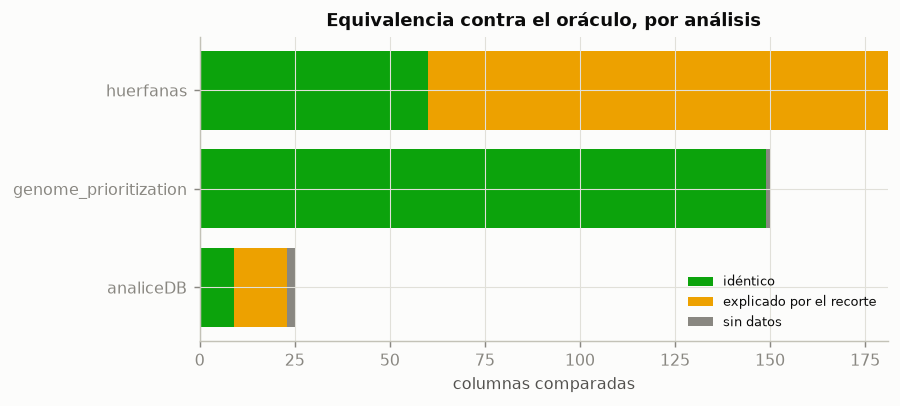

In [8]:
F.dibujar("10_f01_equivalencia");